Market Basket Analysis with Apriori Algorithm


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder


Transactions Dataset

In [2]:
transactions = [
    ['Bread', 'Milk'],
    ['Bread', 'Diapers', 'Beer'],
    ['Milk', 'Diapers', 'Beer'],
    ['Bread', 'Milk', 'Diapers']
]

In [3]:
transactions

[['Bread', 'Milk'],
 ['Bread', 'Diapers', 'Beer'],
 ['Milk', 'Diapers', 'Beer'],
 ['Bread', 'Milk', 'Diapers']]

 Preprocess the Data

In [4]:
transaction_encoder = TransactionEncoder()
encoded_transactions = transaction_encoder.fit(transactions).transform(transactions)
transactions_dataframe = pd.DataFrame(encoded_transactions, columns=transaction_encoder.columns_)

In [5]:
transactions_dataframe

,Beer,Bread,Diapers,Milk
0,False,True,False,True
1,True,True,True,False
2,True,False,True,True
3,False,True,True,True


 Apply Apriori Algorithm

In [7]:
frequent_itemsets = apriori(transactions_dataframe, min_support=0.5, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.50,(Beer)
1,0.75,(Bread)
2,0.75,(Diapers)
3,0.75,(Milk)
4,0.50,"(Diapers, Beer)"
5,0.50,"(Diapers, Bread)"
6,0.50,"(Milk, Bread)"
7,0.50,"(Diapers, Milk)"


 Generate Association Rules

In [8]:
association_rules_df = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
association_rules_df = association_rules_df[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
association_rules_df

,antecedents,consequents,support,confidence,lift
0,(Diapers),(Beer),0.5,0.666667,1.333333
1,(Beer),(Diapers),0.5,1.000000,1.333333
2,(Diapers),(Bread),0.5,0.666667,0.888889
3,(Bread),(Diapers),0.5,0.666667,0.888889
4,(Milk),(Bread),0.5,0.666667,0.888889
5,(Bread),(Milk),0.5,0.666667,0.888889
6,(Diapers),(Milk),0.5,0.666667,0.888889
7,(Milk),(Diapers),0.5,0.666667,0.888889


Top Rules by Lift

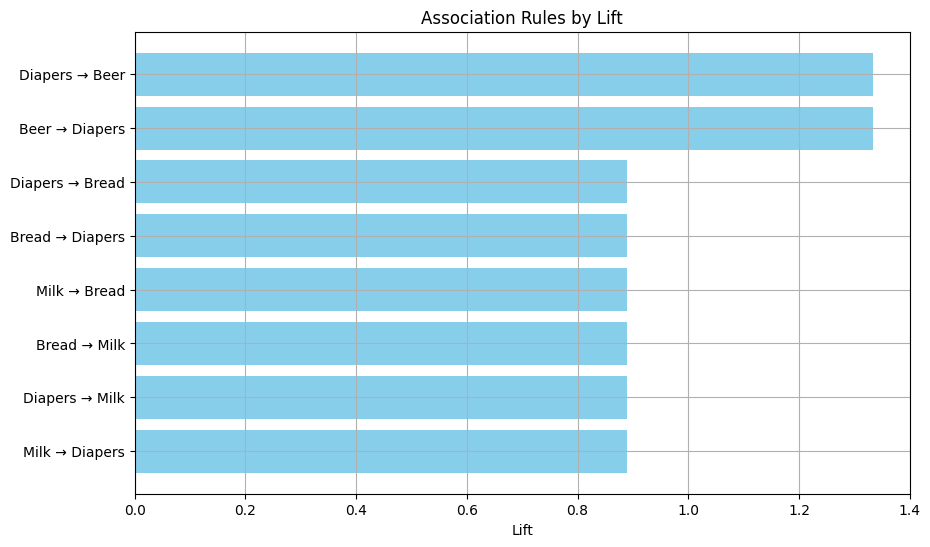

In [9]:
plt.figure(figsize=(10, 6))
plt.barh(
    [f"{list(a)[0]} → {list(c)[0]}" for a, c in zip(association_rules_df['antecedents'], association_rules_df['consequents'])],
    association_rules_df['lift'],
    color='skyblue'
)
plt.xlabel("Lift")
plt.title("Association Rules by Lift")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

Top Rules by Confidence

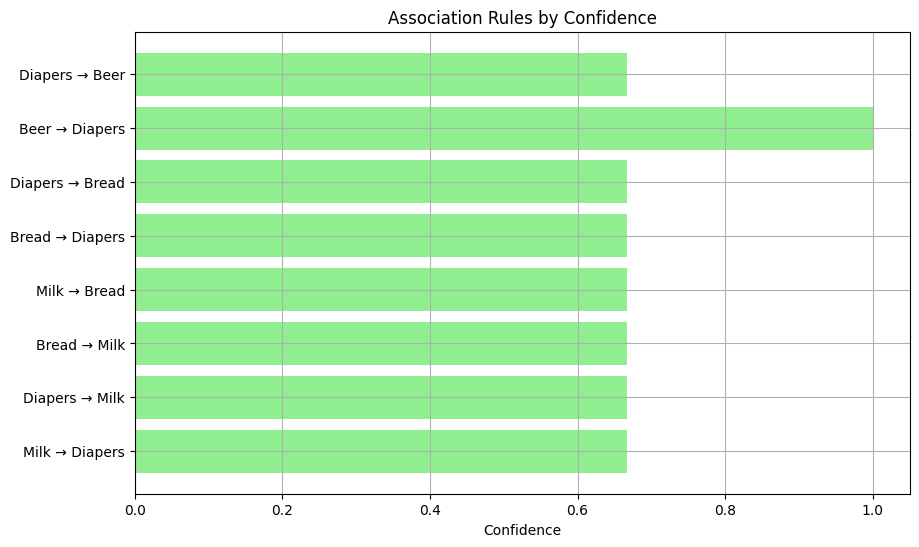

In [10]:
plt.figure(figsize=(10, 6))
plt.barh(
    [f"{list(a)[0]} → {list(c)[0]}" for a, c in zip(association_rules_df['antecedents'], association_rules_df['consequents'])],
    association_rules_df['confidence'],
    color='lightgreen'
)
plt.xlabel("Confidence")
plt.title("Association Rules by Confidence")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

Top Rules by Support

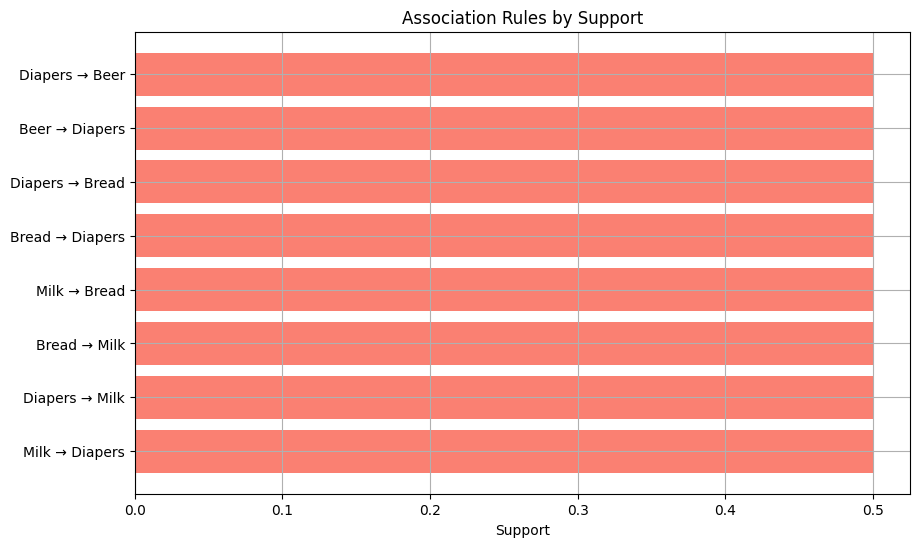

In [11]:
plt.figure(figsize=(10, 6))
plt.barh(
    [f"{list(a)[0]} → {list(c)[0]}" for a, c in zip(association_rules_df['antecedents'], association_rules_df['consequents'])],
    association_rules_df['support'],
    color='salmon'
)
plt.xlabel("Support")
plt.title("Association Rules by Support")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

Display the Frequent Itemsets and Association Rules

In [12]:
print("Frequent Itemsets:")
print(frequent_itemsets)
print("\nAssociation Rules:")
print(association_rules_df)

Frequent Itemsets:
   support          itemsets
0     0.50            (Beer)
1     0.75           (Bread)
2     0.75         (Diapers)
3     0.75            (Milk)
4     0.50   (Diapers, Beer)
5     0.50  (Diapers, Bread)
6     0.50     (Milk, Bread)
7     0.50   (Diapers, Milk)

Association Rules:
  antecedents consequents  support  confidence      lift
0   (Diapers)      (Beer)      0.5    0.666667  1.333333
1      (Beer)   (Diapers)      0.5    1.000000  1.333333
2   (Diapers)     (Bread)      0.5    0.666667  0.888889
3     (Bread)   (Diapers)      0.5    0.666667  0.888889
4      (Milk)     (Bread)      0.5    0.666667  0.888889
5     (Bread)      (Milk)      0.5    0.666667  0.888889
6   (Diapers)      (Milk)      0.5    0.666667  0.888889
7      (Milk)   (Diapers)      0.5    0.666667  0.888889
